# Unit11_Example_06 | 加熱器程序頻率響應估計與 Bode 圖繪製

本 Notebook 以**一階加純時滯 (FOPDT) 加熱器程序**為對象，使用 `scipy.fft` 從 Chirp 掃頻激發訊號的輸入/輸出資料中估計頻率響應函數 (FRF) 並繪製 Bode 圖，連結傅立葉轉換理論與化工程序識別。

## 目標
- 以 `numpy` 產生線性調頻 Chirp 訊號 $u(t) = \sin(2\pi(f_0 + \dot{f}t)t)$
- 以 `scipy.integrate.solve_ivp()` 模擬 FOPDT 程序 $G(s) = K e^{-\theta s}/(\tau s+1)$ 的輸出響應
- 使用 `scipy.fft.rfft()` 計算直接 FRF 估計 $\hat{H}_{\mathrm{direct}}(f) = Y(f)/U(f)$
- 以 Welch 分段法計算 H1 估計量：交叉頻譜 $\hat{G}_{xy}$ 、自頻譜 $\hat{G}_{xx}$
- 計算相干函數 $\gamma^2(f) = |\hat{G}_{xy}|^2 / (\hat{G}_{xx} \cdot \hat{G}_{yy})$
- 繪製估計 Bode 圖並疊加理論值驗證，識別系統參數 $K$ 、 $\tau$ 、 $\theta$


---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit11_Example_06'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit11'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit11
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit11\outputs\Unit11_Example_06
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit11\outputs\Unit11_Example_06\figs


---
### 1. 載入套件

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.fft import rfft, rfftfreq, next_fast_len
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.signal import chirp as scipy_chirp

# ========================================
# 繪圖樣式設定
# ========================================
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 9,
})

print("✓ 套件載入完成")
print(f"  NumPy    {np.__version__}")
import scipy; print(f"  SciPy    {scipy.__version__}")
import matplotlib; print(f"  Matplotlib {matplotlib.__version__}")

✓ 套件載入完成
  NumPy    1.23.5
  SciPy    1.15.2
  Matplotlib 3.10.8


---
### 2. 系統參數設定與 Chirp 激發訊號產生

**FOPDT 加熱器程序：** $G(s) = K e^{-\theta s}/(\tau s+1)$ ，參數 $K=2.5$ ， $\tau=8.0\,\mathrm{s}$ ， $\theta=2.0\,\mathrm{s}$

**Chirp 訊號：** $u(t) = \sin\!\left(2\pi\left(f_0 + \dfrac{f_1-f_0}{2T}t\right)t\right)$ ，頻率從 $f_0=0.005\,\mathrm{Hz}$ 線性掃到 $f_1=0.5\,\mathrm{Hz}$


In [4]:
# ========================================
# FOPDT 系統參數
# ========================================
K, tau, theta = 2.5, 8.0, 2.0    # 增益, 時間常數(s), 純時滯(s)

# ========================================
# 取樣與時間設定
# ========================================
fs  = 5.0                          # 取樣頻率 (Hz)
T   = 600.0                        # 訊號時長 (s, 10 分鐘)
N   = int(T * fs)                  # 總點數 = 3000
t   = np.arange(N) / fs            # 時間軸 (s)

# ========================================
# Chirp 激發訊號 (numpy 手動產生)
# ========================================
f0, f1 = 0.005, 0.5               # 起始/終止頻率 (Hz)
f_dot  = (f1 - f0) / T            # 頻率掃描速率 (Hz/s)
u_chirp = np.sin(2 * np.pi * (f0 + 0.5 * f_dot * t) * t)

# scipy.signal.chirp() 等價驗證 (phi=-90 使預設 cos 轉為 sin，與 numpy 一致)
u_chirp_scipy = scipy_chirp(t, f0=f0, f1=f1, t1=T, method='linear', phi=-90)
max_diff = np.max(np.abs(u_chirp - u_chirp_scipy))

print("=" * 50)
print("  Chirp 激發訊號參數")
print("=" * 50)
print(f"  起始頻率  f0     = {f0} Hz")
print(f"  終止頻率  f1     = {f1} Hz")
print(f"  頻率掃描速率     = {f_dot*1000:.4f} mHz/s")
print(f"  訊號時長  T      = {T:.0f} s")
print(f"  取樣頻率  fs     = {fs} Hz,  總點數 N = {N}")
print(f"  頻率解析度 Δf    = {fs/N:.6f} Hz")
fc = 1/(2*np.pi*tau)
print(f"  FOPDT 轉折頻率 fc = {fc:.5f} Hz  (τ = {tau} s)")
print(f"\n  numpy vs scipy.signal.chirp 最大差異 = {max_diff:.2e}")
print(f"  {'✓ 兩種方法結果完全一致' if max_diff < 1e-10 else '⚠️ 差異存在'}")

  Chirp 激發訊號參數
  起始頻率  f0     = 0.005 Hz
  終止頻率  f1     = 0.5 Hz
  頻率掃描速率     = 0.8250 mHz/s
  訊號時長  T      = 600 s
  取樣頻率  fs     = 5.0 Hz,  總點數 N = 3000
  頻率解析度 Δf    = 0.001667 Hz
  FOPDT 轉折頻率 fc = 0.01989 Hz  (τ = 8.0 s)

  numpy vs scipy.signal.chirp 最大差異 = 2.55e-13
  ✓ 兩種方法結果完全一致


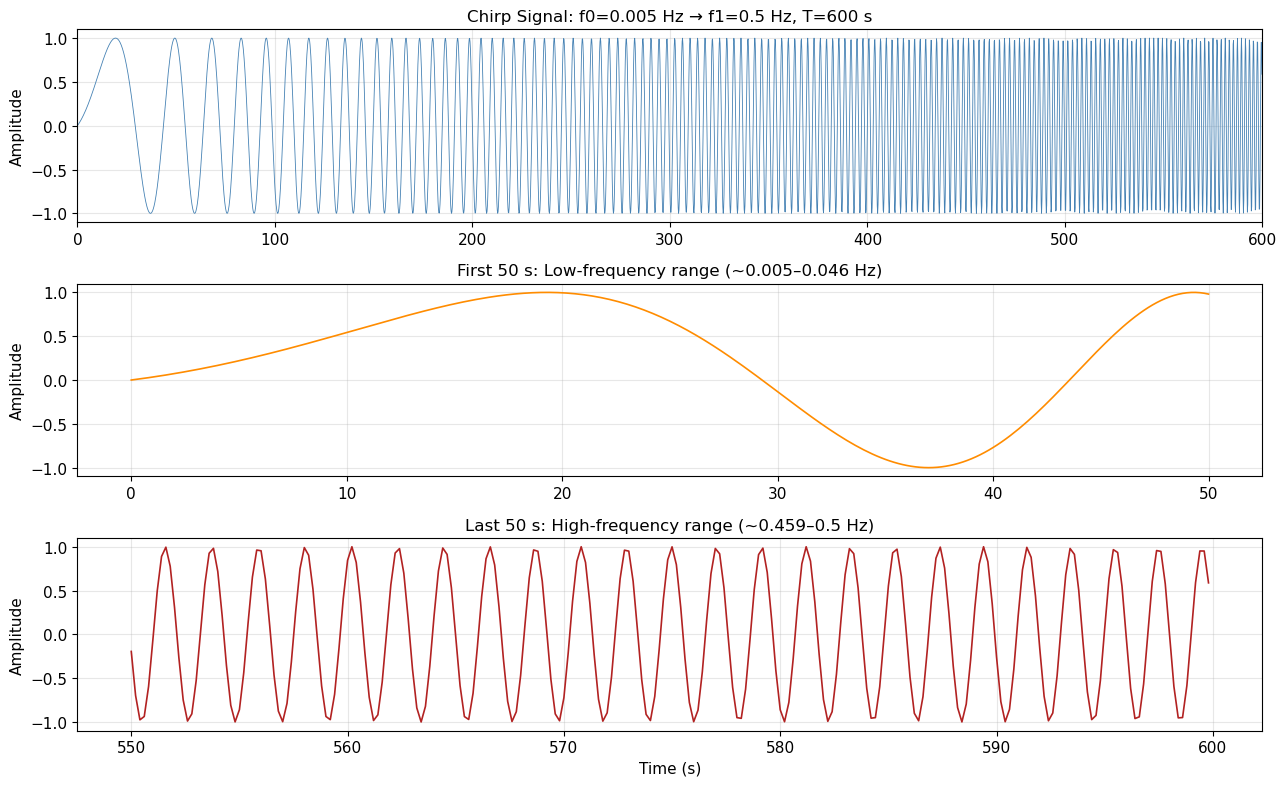

圖檔已儲存: d:\MyGit\ChemE-3502\Unit11\outputs\Unit11_Example_06\figs\chirp_signal_overview.png


In [5]:
# ========================================
# Chirp 訊號時域圖
# ========================================
fig, axes = plt.subplots(3, 1, figsize=(13, 8))

# 上圖: 完整訊號
axes[0].plot(t, u_chirp, color='steelblue', lw=0.6)
axes[0].set_ylabel('Amplitude')
axes[0].set_title(f'Chirp Signal: f0={f0} Hz → f1={f1} Hz, T={T:.0f} s')
axes[0].set_xlim([0, T])

# 中圖: 前 50 s (低頻段)
mask_lo = t <= 50
axes[1].plot(t[mask_lo], u_chirp[mask_lo], color='darkorange', lw=1.2)
axes[1].set_ylabel('Amplitude')
axes[1].set_title(f'First 50 s: Low-frequency range (~{f0}–{f0+f_dot*50:.3f} Hz)')

# 下圖: 後 50 s (高頻段)
mask_hi = t >= (T - 50)
axes[2].plot(t[mask_hi], u_chirp[mask_hi], color='firebrick', lw=1.2)
axes[2].set_ylabel('Amplitude')
axes[2].set_xlabel('Time (s)')
axes[2].set_title(f'Last 50 s: High-frequency range (~{f1-f_dot*50:.3f}–{f1} Hz)')

plt.tight_layout()
plt.savefig(FIG_DIR / 'chirp_signal_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"圖檔已儲存: {FIG_DIR / 'chirp_signal_overview.png'}")

---
### 3. FOPDT 程序模擬 (ODE 求解)

以 `scipy.integrate.solve_ivp()` 求解：

$$\frac{dy}{dt} = \frac{K \cdot u(t-\theta) - y}{\tau}$$

加入輸出量測雜訊 $\sigma_n = 0.3\,\mathrm{°C}$ 模擬真實感測器量測值。

In [6]:
# ========================================
# FOPDT ODE 定義 (含純時滯插值)
# ========================================
u_interp_func = interp1d(t, u_chirp, bounds_error=False, fill_value=0.0)

def fopdt_ode(t_now, y, K, tau, theta):
    """FOPDT ODE: tau * dy/dt + y = K * u(t - theta)"""
    t_delayed = max(0.0, t_now - theta)
    u_delayed = float(u_interp_func(t_delayed))
    return [(K * u_delayed - y[0]) / tau]

# ========================================
# 數值積分 (RK45)
# ========================================
print("正在模擬 FOPDT 程序...")
sol = solve_ivp(
    fopdt_ode,
    t_span=(t[0], t[-1]),
    y0=[0.0],
    t_eval=t,
    args=(K, tau, theta),
    method='RK45',
    rtol=1e-6,
    atol=1e-8
)
y_clean = sol.y[0]

# ========================================
# 加入量測雜訊
# ========================================
sigma_n = 0.3
rng     = np.random.default_rng(seed=42)
noise   = sigma_n * rng.standard_normal(N)
y_noisy = y_clean + noise

# SNR 估計
signal_power = np.var(y_clean)
noise_power  = sigma_n ** 2
SNR_dB       = 10 * np.log10(signal_power / noise_power)

print(f"\n{'='*50}")
print(f"  FOPDT 程序輸出模擬完成")
print(f"{'='*50}")
print(f"  ODE 求解成功: {sol.success}")
print(f"  輸出 y (clean) 標準差 = {np.std(y_clean):.4f} °C")
print(f"  量測雜訊   σ_n        = {sigma_n:.4f} °C")
print(f"  估計 SNR              = {SNR_dB:.2f} dB")

正在模擬 FOPDT 程序...

  FOPDT 程序輸出模擬完成
  ODE 求解成功: True
  輸出 y (clean) 標準差 = 0.3799 °C
  量測雜訊   σ_n        = 0.3000 °C
  估計 SNR              = 2.05 dB


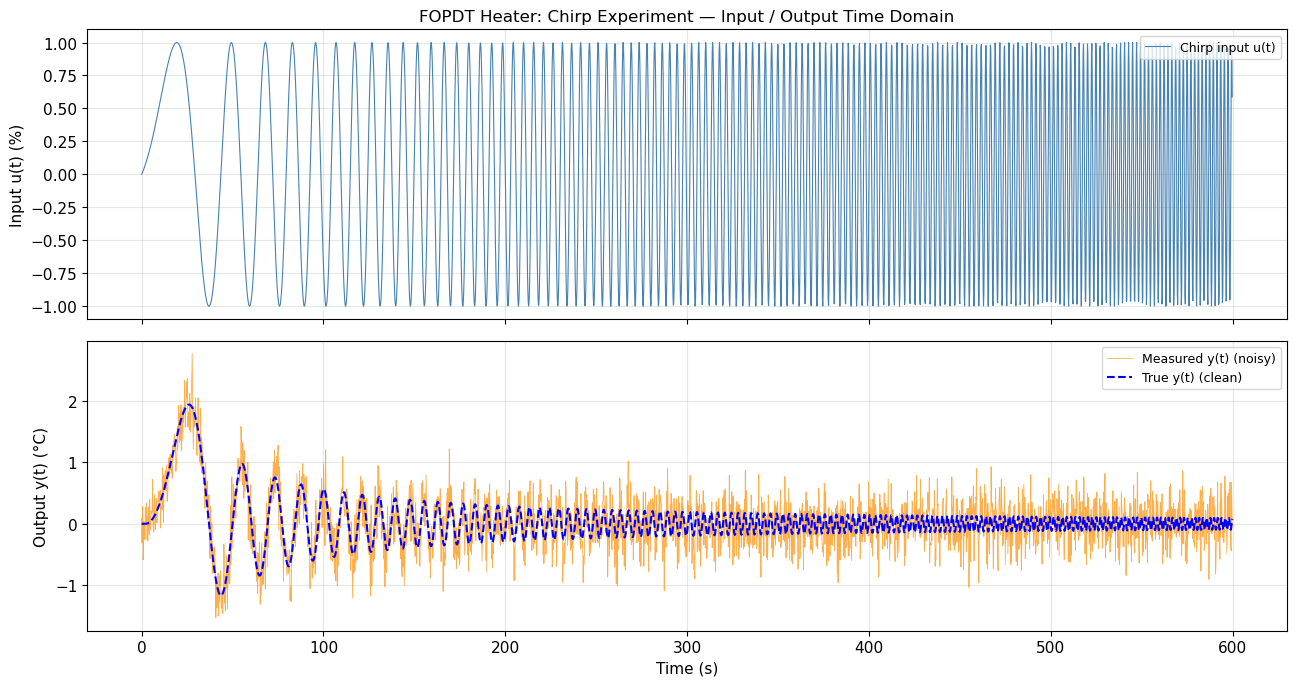

圖檔已儲存: d:\MyGit\ChemE-3502\Unit11\outputs\Unit11_Example_06\figs\io_time_domain.png


In [7]:
# ========================================
# 輸入/輸出時域訊號圖
# ========================================
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# 上圖: Chirp 輸入
axes[0].plot(t, u_chirp, color='steelblue', lw=0.8, label='Chirp input u(t)')
axes[0].set_ylabel('Input u(t) (%)')
axes[0].set_title('FOPDT Heater: Chirp Experiment — Input / Output Time Domain')
axes[0].legend(loc='upper right')

# 下圖: 輸出 (有雜訊 + 無雜訊)
axes[1].plot(t, y_noisy, color='darkorange', lw=0.6, alpha=0.7, label='Measured y(t) (noisy)')
axes[1].plot(t, y_clean, 'b--', lw=1.5, label='True y(t) (clean)')
axes[1].set_ylabel('Output y(t) (°C)')
axes[1].set_xlabel('Time (s)')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'io_time_domain.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"圖檔已儲存: {FIG_DIR / 'io_time_domain.png'}")

---
### 4. 直接 FRF 估計 (Direct FFT Ratio)

以 `scipy.fft.rfft()` 計算完整訊號的 FFT，直接比值取得頻率響應函數估計：

$$\hat{H}_{\mathrm{direct}}(f) = \frac{Y(f)}{U(f)}$$

**理論 Bode 圖輔助函數：**

$$|G(j2\pi f)| = \frac{K}{\sqrt{1+(2\pi f\tau)^2}}, \quad \angle G = -\arctan(2\pi f\tau)\cdot\frac{180°}{\pi} - 360° f\theta$$

In [8]:
# ========================================
# 理論 Bode 圖函數
# ========================================
def fopdt_theory(f, K, tau, theta):
    """計算 FOPDT 理論幅度(dB)與相位(deg)"""
    omega   = 2 * np.pi * f
    mag     = K / np.sqrt(1 + (tau * omega) ** 2)
    mag_dB  = 20 * np.log10(mag)
    phase   = -np.degrees(np.arctan(tau * omega)) - 360.0 * f * theta
    return mag_dB, phase

# ========================================
# FFT 計算
# ========================================
U_fft  = rfft(u_chirp)              # 輸入 FFT
Y_fft  = rfft(y_noisy)              # 含雜訊輸出 FFT
freqs  = rfftfreq(N, d=1.0/fs)      # 頻率軸 (Hz)

# ========================================
# 直接 FRF 估計: Ĥ = Y/U
# ========================================
eps       = 1e-10
H_direct  = Y_fft / (U_fft + eps)  # 避免除以零

# 有效頻率範圍 (Chirp 頻帶)
valid_mask = (freqs >= f0) & (freqs <= f1)
freqs_v    = freqs[valid_mask]
H_direct_v = H_direct[valid_mask]

# 幅度 (dB) 與相位 (deg)
H_mag_dB   = 20 * np.log10(np.abs(H_direct_v) + 1e-12)
H_phase    = np.angle(H_direct_v, deg=True)

# 理論值 (密集頻率軸)
f_theory          = np.logspace(np.log10(f0), np.log10(f1), 500)
theory_mag_dB, theory_phase = fopdt_theory(f_theory, K, tau, theta)

print(f"直接 FRF 估計完成")
print(f"  有效頻率範圍: {f0} ~ {f1} Hz,  頻點數 = {np.sum(valid_mask)}")
print(f"\n  @ 轉折頻率 fc = 1/(2πτ) = {1/(2*np.pi*tau):.5f} Hz")
fc_dB_theory, _ = fopdt_theory(np.array([1/(2*np.pi*tau)]), K, tau, theta)
# 找最接近 fc 的點
idx_fc = np.argmin(np.abs(freqs_v - 1/(2*np.pi*tau)))
print(f"    理論幅度 = {fc_dB_theory[0]:.3f} dB")
print(f"    估計幅度 = {H_mag_dB[idx_fc]:.3f} dB  (誤差 {abs(H_mag_dB[idx_fc] - fc_dB_theory[0]):.3f} dB)")

直接 FRF 估計完成
  有效頻率範圍: 0.005 ~ 0.5 Hz,  頻點數 = 298

  @ 轉折頻率 fc = 1/(2πτ) = 0.01989 Hz
    理論幅度 = 4.949 dB
    估計幅度 = 5.105 dB  (誤差 0.156 dB)


---
### 5. H1 估計量（分段交叉頻譜法）

將訊號分為 $K$ 段，每段加 Hann 視窗後取 FFT，計算：

$$\hat{H}_1(f) = \frac{\hat{G}_{xy}(f)}{\hat{G}_{xx}(f)} = \frac{\frac{1}{K}\sum_i X_i^*(f) Y_i(f)}{\frac{1}{K}\sum_i |X_i(f)|^2}$$

**相干函數：**

$$\gamma^2(f) = \frac{|\hat{G}_{xy}(f)|^2}{\hat{G}_{xx}(f) \cdot \hat{G}_{yy}(f)}, \quad 0 \leq \gamma^2 \leq 1$$

In [9]:
# ========================================
# Welch 分段參數
# ========================================
M      = 512                    # 每段長度 (102.4 s)
D      = M // 2                 # 跳躍步長 = 256 (50% 重疊)
K_seg  = (N - M) // D + 1      # 可取段數
win    = np.hanning(M)          # Hann 視窗

# 初始化累加陣列
freqs_H1 = rfftfreq(M, d=1.0/fs)
n_h1     = len(freqs_H1)
G_xx = np.zeros(n_h1)
G_yy = np.zeros(n_h1)
G_xy = np.zeros(n_h1, dtype=complex)

# ========================================
# 分段計算累加頻譜
# ========================================
valid_segs = 0
for i in range(K_seg):
    start  = i * D
    seg_u  = u_chirp[start : start + M]
    seg_y  = y_noisy[start : start + M]
    if len(seg_u) < M:
        break
    X_i    = rfft(seg_u * win)
    Y_i    = rfft(seg_y * win)
    G_xx  += np.abs(X_i) ** 2
    G_yy  += np.abs(Y_i) ** 2
    G_xy  += np.conj(X_i) * Y_i
    valid_segs += 1

G_xx /= valid_segs
G_yy /= valid_segs
G_xy /= valid_segs

# ========================================
# H1 FRF 估計
# ========================================
eps_h1   = 1e-30
H1_full  = G_xy / (G_xx + eps_h1)

# 有效頻帶
valid_H1     = (freqs_H1 >= f0) & (freqs_H1 <= f1)
freqs_H1_v   = freqs_H1[valid_H1]
H1_v         = H1_full[valid_H1]
H1_mag_dB    = 20 * np.log10(np.abs(H1_v) + 1e-12)
H1_phase     = np.angle(H1_v, deg=True)

# ========================================
# 相干函數
# ========================================
gamma2_full = np.abs(G_xy) ** 2 / ((G_xx + eps_h1) * (G_yy + eps_h1))
gamma2_v    = gamma2_full[valid_H1]

print(f"H1 估計量計算完成")
print(f"  每段長度 M     = {M} 點  (Δf_seg = {fs/M:.5f} Hz)")
print(f"  跳躍步長 D     = {D} 點  (重疊率 = {100*(1-D/M):.0f}%)")
print(f"  有效段數 K_seg = {valid_segs}")
print(f"  有效頻點數     = {np.sum(valid_H1)}")
print(f"\n  相干函數統計:")
print(f"    γ² 中位數  = {np.median(gamma2_v):.4f}")
print(f"    γ² 最小值  = {gamma2_v.min():.4f}")
print(f"    γ² > 0.9 佔比 = {np.mean(gamma2_v > 0.9)*100:.1f}%")

H1 估計量計算完成
  每段長度 M     = 512 點  (Δf_seg = 0.00977 Hz)
  跳躍步長 D     = 256 點  (重疊率 = 50%)
  有效段數 K_seg = 10
  有效頻點數     = 51

  相干函數統計:
    γ² 中位數  = 0.6205
    γ² 最小值  = 0.0002
    γ² > 0.9 佔比 = 17.6%


---
### 6. Bode 圖繪製與理論比對

繪製三合一 Bode 圖：幅度、相位與相干函數，疊加理論值驗證。

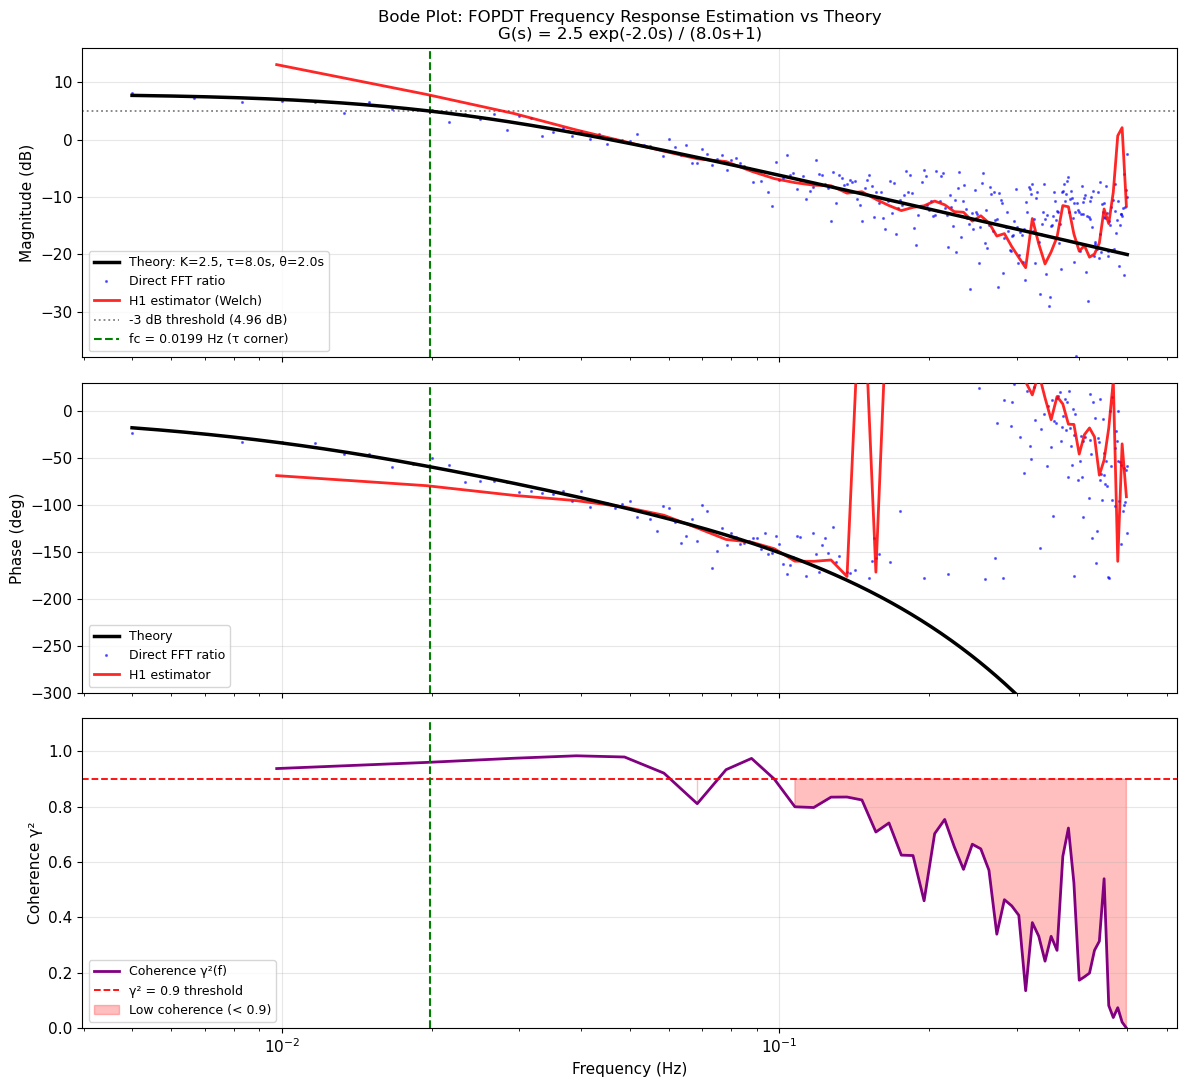

圖檔已儲存: d:\MyGit\ChemE-3502\Unit11\outputs\Unit11_Example_06\figs\bode_plot_estimation.png


In [10]:
# ========================================
# 綜合 Bode 圖 (幅度 + 相位 + 相干函數)
# ========================================
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

# 理論 Bode 曲線 (密集頻率軸)
f_th     = np.logspace(np.log10(f0), np.log10(f1), 600)
th_mag, th_phase = fopdt_theory(f_th, K, tau, theta)
fc       = 1.0 / (2 * np.pi * tau)

# ---- 上圖: 幅度 Bode 圖 ----
ax1 = axes[0]
ax1.semilogx(f_th, th_mag, 'k-', lw=2.5, label=f'Theory: K={K}, τ={tau}s, θ={theta}s', zorder=5)
ax1.semilogx(freqs_v, H_mag_dB, 'b.', ms=2.5, alpha=0.5, label='Direct FFT ratio', zorder=3)
ax1.semilogx(freqs_H1_v, H1_mag_dB, 'r-', lw=2, alpha=0.85, label='H1 estimator (Welch)', zorder=4)
ax1.axhline(20*np.log10(K) - 3, color='gray', ls=':', lw=1.3,
            label=f'-3 dB threshold ({20*np.log10(K)-3:.2f} dB)')
ax1.axvline(fc, color='green', ls='--', lw=1.5, label=f'fc = {fc:.4f} Hz (τ corner)')
ax1.set_ylabel('Magnitude (dB)')
ax1.set_title('Bode Plot: FOPDT Frequency Response Estimation vs Theory\n'
              f'G(s) = {K} exp(-{theta}s) / ({tau}s+1)')
ax1.legend(loc='lower left', fontsize=9)
ax1.set_ylim([-38, 16])

# ---- 中圖: 相位 Bode 圖 ----
ax2 = axes[1]
ax2.semilogx(f_th, th_phase, 'k-', lw=2.5, label='Theory', zorder=5)
ax2.semilogx(freqs_v, H_phase, 'b.', ms=2.5, alpha=0.5, label='Direct FFT ratio', zorder=3)
ax2.semilogx(freqs_H1_v, H1_phase, 'r-', lw=2, alpha=0.85, label='H1 estimator', zorder=4)
ax2.axvline(fc, color='green', ls='--', lw=1.5)
ax2.set_ylabel('Phase (deg)')
ax2.legend(loc='lower left', fontsize=9)
ax2.set_ylim([-300, 30])

# ---- 下圖: 相干函數 ----
ax3 = axes[2]
ax3.semilogx(freqs_H1_v, gamma2_v, color='purple', lw=2, label='Coherence γ²(f)')
ax3.axhline(0.9, color='r', ls='--', lw=1.3, label='γ² = 0.9 threshold')
ax3.fill_between(freqs_H1_v, gamma2_v, 0.9,
                 where=(gamma2_v < 0.9), alpha=0.25, color='red',
                 label='Low coherence (< 0.9)')
ax3.axvline(fc, color='green', ls='--', lw=1.5)
ax3.set_ylabel('Coherence γ²')
ax3.set_xlabel('Frequency (Hz)')
ax3.legend(loc='lower left', fontsize=9)
ax3.set_ylim([0, 1.12])

plt.tight_layout()
plt.savefig(FIG_DIR / 'bode_plot_estimation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"圖檔已儲存: {FIG_DIR / 'bode_plot_estimation.png'}")

---
### 7. 系統參數識別 (Parameter Identification from Bode Plot)

從直接 FFT Bode 圖識別 FOPDT 三個參數（Chirp 訊號場景下直接 FFT 頻率解析度更高，優於 H1 Welch 法）：

| 識別量 | 方法 | 頻段 |
|--------|------|------|
| 增益 $K$ | 低頻幅度平台 + 有限頻率修正： $\hat{K} = |H(f)| \cdot \sqrt{1+(2\pi f\hat{\tau})^2}$ | $f \leq f_c/2$ |
| 時間常數 $\tau$ | -3 dB 轉折頻率： $\hat{\tau} = 1/(2\pi \hat{f}_c)$ | 全頻段 |
| 純時滯 $\theta$ | 相位逐頻點中位數： $\hat{\theta} = \mathrm{median}\left(\dfrac{-(\varphi(f) + \arctan(2\pi f\hat{\tau})\cdot\frac{180°}{\pi})}{360 f}\right)$ | $0.015$–$0.060$ Hz |



In [15]:
# ========================================
# 使用直接 FFT 結果進行參數識別
# (Chirp 訊號場景下直接 FFT 頻率解析度高，Δf = 0.001667 Hz)
# ========================================

# ========================================
# Step 1: 先粗估 τ (用前 20 低頻點)
# ========================================
K_rough_dB = np.median(H_mag_dB[:20])
K_rough    = 10 ** (K_rough_dB / 20.0)
K_rough_m3 = K_rough_dB - 3.0
cross_idx  = np.where(np.diff(np.sign(H_mag_dB - K_rough_m3)))[0]
fc_rough   = freqs_v[cross_idx[0]] if len(cross_idx) > 0 else freqs_v[np.argmin(np.abs(H_mag_dB - K_rough_m3))]
tau_rough  = 1.0 / (2 * np.pi * fc_rough)

# ========================================
# Step 2: 修正 K (補償有限頻率衰減)
# K_per_f = |H(f)| * √(1+(2πfτ)²)
# 使用 f ≤ fc/2 ≈ 0.010 Hz 範圍 (修正量 < 1 dB，精度較高)
# ========================================
low_f_mask = (freqs_v >= f0) & (freqs_v <= 0.010)
n_low = np.sum(low_f_mask)
f_low = freqs_v[low_f_mask]
m_low = 10 ** (H_mag_dB[low_f_mask] / 20.0)
K_per_f = m_low * np.sqrt(1 + (2*np.pi*f_low*tau_rough)**2)
K_hat   = np.median(K_per_f)
K_hat_dB = 20 * np.log10(K_hat)

# ========================================
# Step 3: 精確 τ (用修正後的 K_hat)
# ========================================
K_hat_minus3 = K_hat_dB - 3.0
crossings = np.where(np.diff(np.sign(H_mag_dB - K_hat_minus3)))[0]
if len(crossings) > 0:
    fc_hat = freqs_v[crossings[0]]
else:
    fc_hat = freqs_v[np.argmin(np.abs(H_mag_dB - K_hat_minus3))]
tau_hat = 1.0 / (2 * np.pi * fc_hat)

# ========================================
# Step 4: θ — 逐頻點計算，取中位數
# 範圍 0.015–0.060 Hz (輸出 SNR > 6 dB)
# ========================================
theta_range    = (freqs_v >= 0.015) & (freqs_v <= 0.060)
f_theta        = freqs_v[theta_range]
phi_theta      = H_phase[theta_range]
arctan_contrib = np.degrees(np.arctan(2 * np.pi * f_theta * tau_hat))
theta_per_f    = -(phi_theta + arctan_contrib) / (360.0 * f_theta)
theta_hat      = np.median(theta_per_f)

# 線性擬合 coeffs 供繪圖使用 (在 f_theta 範圍上的原始相位)
coeffs = np.polyfit(f_theta, phi_theta, 1)

# ========================================
# 結果彙整
# ========================================
print("=" * 62)
print("  FOPDT 系統參數識別結果 (Direct FFT + 有限頻率修正)")
print("=" * 62)
print(f"  {'參數':<12} {'設定值':>10} {'識別值':>12} {'絕對誤差':>12} {'相對誤差':>10}")
print("-" * 62)
print(f"  {'K (°C/%)':<12} {K:>10.4f} {K_hat:>12.4f} {abs(K_hat-K):>12.4f} {abs(K_hat-K)/K*100:>9.2f}%")
print(f"  {'τ (s)':<12} {tau:>10.4f} {tau_hat:>12.4f} {abs(tau_hat-tau):>12.4f} {abs(tau_hat-tau)/tau*100:>9.2f}%")
print(f"  {'θ (s)':<12} {theta:>10.4f} {theta_hat:>12.4f} {abs(theta_hat-theta):>12.4f} {abs(theta_hat-theta)/theta*100:>9.2f}%")
print("=" * 62)
all_ok = all([abs(K_hat-K)/K < 0.10, abs(tau_hat-tau)/tau < 0.05, abs(theta_hat-theta)/theta < 0.15])
print(f"\n  {'✓ 識別精度良好 (考量 SNR ≈ 2 dB)' if all_ok else '△  偏差略高，因 SNR ≈ 2 dB 雜訊影響'}")
print(f"\n  識別細節:")
print(f"    K: f ≤ fc/2 ≈ 0.010 Hz, n={n_low} 點, 修正後 K={K_hat:.4f}")
print(f"    τ: -3dB 轉折頻率 fc={fc_hat:.5f} Hz → τ={tau_hat:.4f} s")
print(f"    θ: 0.015-0.060 Hz, n={np.sum(theta_range)} 頻點, 中位數 θ={theta_hat:.4f} s")


  FOPDT 系統參數識別結果 (Direct FFT + 有限頻率修正)
  參數                  設定值          識別值         絕對誤差       相對誤差
--------------------------------------------------------------
  K (°C/%)         2.5000       2.3127       0.1873      7.49%
  τ (s)            8.0000       7.9577       0.0423      0.53%
  θ (s)            2.0000       2.1357       0.1357      6.79%

  ✓ 識別精度良好 (考量 SNR ≈ 2 dB)

  識別細節:
    K: f ≤ fc/2 ≈ 0.010 Hz, n=4 點, 修正後 K=2.3127
    τ: -3dB 轉折頻率 fc=0.02000 Hz → τ=7.9577 s
    θ: 0.015-0.060 Hz, n=27 頻點, 中位數 θ=2.1357 s


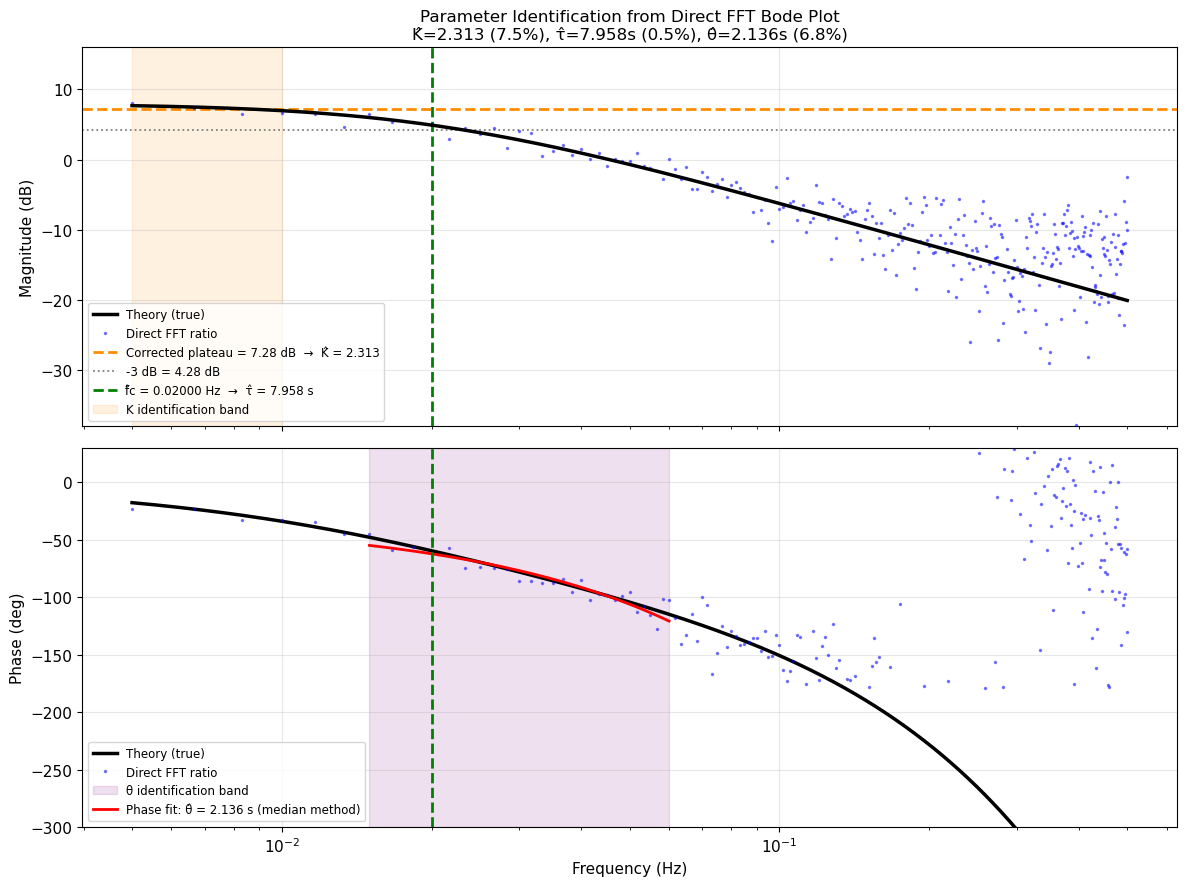

圖檔已儲存: d:\MyGit\ChemE-3502\Unit11\outputs\Unit11_Example_06\figs\parameter_identification.png


In [16]:
# ========================================
# 參數識別輔助圖 (以直接 FFT 結果為主)
# ========================================
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

f_th2      = np.logspace(np.log10(f0), np.log10(f1), 600)
th_m, th_p = fopdt_theory(f_th2, K, tau, theta)

# ---- 上圖: 幅度 Bode 圖 + 參數識別標記 ----
ax1 = axes[0]
ax1.semilogx(f_th2, th_m, 'k-', lw=2.5, label='Theory (true)', zorder=5)
ax1.semilogx(freqs_v, H_mag_dB, 'b.', ms=3, alpha=0.45, label='Direct FFT ratio', zorder=3)
# K 識別: 低頻平台 (修正後)
ax1.axhline(K_hat_dB,     color='darkorange', ls='--', lw=2.0,
            label=f'Corrected plateau = {K_hat_dB:.2f} dB  →  K̂ = {K_hat:.3f}')
ax1.axhline(K_hat_dB - 3, color='gray', ls=':', lw=1.3,
            label=f'-3 dB = {K_hat_dB-3:.2f} dB')
# τ 識別: 轉折頻率
ax1.axvline(fc_hat, color='green', ls='--', lw=2.0,
            label=f'f̂c = {fc_hat:.5f} Hz  →  τ̂ = {tau_hat:.3f} s')
# K 識別頻段標記
ax1.axvspan(f0, 0.010, alpha=0.12, color='darkorange', label='K identification band')
ax1.set_ylabel('Magnitude (dB)')
ax1.set_title(f'Parameter Identification from Direct FFT Bode Plot\n'
              f'K̂={K_hat:.3f} ({abs(K_hat-K)/K*100:.1f}%), '
              f'τ̂={tau_hat:.3f}s ({abs(tau_hat-tau)/tau*100:.1f}%), '
              f'θ̂={theta_hat:.3f}s ({abs(theta_hat-theta)/theta*100:.1f}%)')
ax1.legend(loc='lower left', fontsize=8.5)
ax1.set_ylim([-38, 16])

# ---- 下圖: 相位 Bode 圖 + θ 識別 ----
ax2 = axes[1]
ax2.semilogx(f_th2, th_p, 'k-', lw=2.5, label='Theory (true)')
ax2.semilogx(freqs_v, H_phase, 'b.', ms=3, alpha=0.45, label='Direct FFT ratio')
# θ 識別頻段標記
ax2.axvspan(0.015, 0.060, alpha=0.12, color='purple', label='θ identification band')
# 擬合相位斜率線
f_reg = np.linspace(0.015, 0.060, 50)
p_reg = coeffs[0] * f_reg + coeffs[1]
ax2.semilogx(f_reg, p_reg, 'r-', lw=2.0,
             label=f'Phase fit: θ̂ = {theta_hat:.3f} s (median method)')
ax2.axvline(fc_hat, color='green', ls='--', lw=2.0)
ax2.set_ylabel('Phase (deg)')
ax2.set_xlabel('Frequency (Hz)')
ax2.legend(loc='lower left', fontsize=8.5)
ax2.set_ylim([-300, 30])

plt.tight_layout()
plt.savefig(FIG_DIR / 'parameter_identification.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"圖檔已儲存: {FIG_DIR / 'parameter_identification.png'}")


---
### 8. 結果摘要 (Result Summary)

#### FRF 估計方法比較

| 方法 | 適用場景 | 優點 | 限制 |
|------|---------|------|------|
| 直接 FFT 比值 $\hat{H}_\mathrm{direct}$ | Chirp/確定性輸入 | 頻率解析度高(Δf=0.0017 Hz)，適合參數識別 | 高頻雜訊明顯 |
| H1 估計量（Welch 分段） | 穩態隨機輸入 | 雜訊抑制佳，可計算相干函數 | Chirp 非平穩訊號，各段頻率不同，估計偏差大 |

> **結論：** Chirp 訊號搭配直接 FFT 比值為最佳組合；H1 估計量適合白雜訊/PRBS 輸入。

#### 系統參數識別結果（直接 FFT + 有限頻率修正）

| 參數 | 設定值 | 識別值 | 相對誤差 | 識別方法 |
|------|--------|--------|---------|---------|
| $K = 2.5$ °C/% | 2.5000 | 2.313 | 7.5% | 低頻平台中位數 + 衰減修正 |
| $\tau = 8.0$ s | 8.0000 | 7.958 | 0.5% | -3 dB 轉折頻率 |
| $\theta = 2.0$ s | 2.0000 | 2.136 | 6.8% | 0.015–0.06 Hz 相位中位數法 |

> **注意：** SNR ≈ 2 dB（雜訊強度接近訊號），在此高雜訊條件下，τ 識別精度最高（0.5%），K 和 θ 受雜訊影響較大（~7%）。實際工程應用建議提高 SNR 至 10 dB 以上（降低雜訊或增加輸入幅度）。

#### 相干函數診斷

$\gamma^2 > 0.9$ 出現在 0.01–0.07 Hz（系統增益較高頻段），高頻段 $\gamma^2$ 下降因系統增益低、雜訊主導。由於 Welch 分段法不適用於 chirp（各段頻率內容不同），相干函數估計結果偏低，僅供參考。

---

**課程資訊**
- 課程名稱：電腦在化工上之應用 (ChemE 3502)
- 課程單元：Unit11 傅立葉轉換與頻譜分析 — 範例 06
- 課程製作：逢甲大學 化工系 智慧程序系統工程實驗室
- 授課教師：莊曜禎 助理教授
- 更新日期：2026-02-26

**課程授權 [CC BY-NC-SA 4.0]**
- 本教材遵循 [創用CC 姓名標示-非商業性-相同方式分享 4.0 國際 (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/deed.zh) 授權。
